In [1]:
# Personal parameters
SID4 = 640
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A, CLS_B = (SID4 % 10), ((SID4 // 10) % 10)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)

SID4: 640
SEED: 640
SLICE: 640
HP_ID: 4
CLS_A: 0
CLS_B: 4


# Task 1: GPT-Style LLM from Scratch

## 1.1 Data Preprocessing

### 1.1.1 Load the Dataset and Inspect the Dataset

TinyStories is read one story at a time using `<|endoftext|>` as the
story delimiter. Empty entries are skipped. Case, punctuation, spaces,
and internal line breaks are preserved.

Each character is one token. Story delimiters are removed during
reading; two newline characters will separate stories in the encoded
text stream.

In [3]:
from pathlib import Path
from itertools import islice

# Locate shared data using the repository structure.
for folder in [Path.cwd(), *Path.cwd().parents]:
    data_dir = folder / "task1_llm" / "data"
    if data_dir.is_dir():
        break
else:
    raise FileNotFoundError("Cannot find task1_llm/data")

train_path = data_dir / "TinyStories-train.txt"
valid_path = data_dir / "TinyStories-valid.txt"


def iter_stories(path):
    """Yield one non-empty story at a time."""
    lines = []

    with path.open("r", encoding="utf-8") as file:
        for line in file:
            if line.strip() == "<|endoftext|>":
                story = "".join(lines).strip()
                if story:
                    yield story
                lines = []
            else:
                lines.append(line)

    story = "".join(lines).strip()
    if story:
        yield story


# Inspect both files.
for path in (train_path, valid_path):
    if not path.is_file():
        raise FileNotFoundError(path.name)

    print(f"{path.name}: {path.stat().st_size / 1e6:.1f} MB")

# Preview only; formal sampling follows in Section 1.1.2.
preview_stories = list(islice(iter_stories(train_path), 2))

for index, story in enumerate(preview_stories, start=1):
    print(f"\nStory {index} | {len(story):,} characters")
    print(story)

TinyStories-train.txt: 1924.3 MB
TinyStories-valid.txt: 19.4 MB

Story 1 | 699 characters
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.
Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."
Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.

Story 2 | 703 characters
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and st

### 1.1.2 Prepare Training and Validation Sets

The required 100K/10K sizes are interpreted as story counts. Independently sample 100,000 training stories and 10,000 validation stories while preserving the official train–validation boundary.

Reservoir sampling with fixed seeds makes the selection reproducible. SHA-256 hashes identify exact duplicates in the parsed story text.
Duplicate stories are skipped, and selected training stories are excluded from validation sampling.

Sampling scans each source file but retains only the selected story texts and hashes of previously encountered stories.

In [5]:
import hashlib
import random

TRAIN_SIZE = 100_000
VALID_SIZE = 10_000
TRAIN_SEED = SEED
VALID_SEED = SEED + 1


def story_hash(story):
    return hashlib.sha256(story.encode("utf-8")).digest()


def sample_unique_stories(path, size, seed, excluded_hashes=None):
    """Uniformly sample distinct eligible stories."""
    rng = random.Random(seed)
    excluded = excluded_hashes if excluded_hashes is not None else set()

    seen = set()
    sample = []
    eligible_count = 0

    for story in iter_stories(path):
        digest = story_hash(story)

        if digest in seen or digest in excluded:
            continue

        seen.add(digest)
        eligible_count += 1

        if len(sample) < size:
            sample.append(story)
        else:
            position = rng.randrange(eligible_count)
            if position < size:
                sample[position] = story

    if len(sample) != size:
        raise ValueError(
            f"Requested {size:,} stories; found {eligible_count:,} eligible."
        )

    rng.shuffle(sample)
    return sample


# Independently select the two subsets.
train_stories = sample_unique_stories(
    train_path, TRAIN_SIZE, TRAIN_SEED
)
train_hashes = {story_hash(story) for story in train_stories}
print("Training sampling complete.")

valid_stories = sample_unique_stories(
    valid_path, VALID_SIZE, VALID_SEED,
    excluded_hashes=train_hashes,
)
valid_hashes = {story_hash(story) for story in valid_stories}

# Check sizes, exact duplicates, and overlap.
train_duplicates = len(train_stories) - len(train_hashes)
valid_duplicates = len(valid_stories) - len(valid_hashes)
overlap = len(train_hashes & valid_hashes)

assert len(train_stories) == TRAIN_SIZE
assert len(valid_stories) == VALID_SIZE
assert train_duplicates == valid_duplicates == overlap == 0

print(f"\nTraining stories: {len(train_stories):,}")
print(f"Validation stories: {len(valid_stories):,}")
print(f"Training duplicates: {train_duplicates}")
print(f"Validation duplicates: {valid_duplicates}")
print(f"Train–validation overlap: {overlap}")
print(f"Sampling seeds: train={TRAIN_SEED}, validation={VALID_SEED}")

print("\nFirst selected training story:")
print(train_stories[0][:300])

Training sampling complete.

Training stories: 100,000
Validation stories: 10,000
Training duplicates: 0
Validation duplicates: 0
Train–validation overlap: 0
Sampling seeds: train=640, validation=641

First selected training story:
Once upon a time there was a little girl who was very grumpy. She scrunched up her face and complained a lot. One day, her mommy told her to take a break and relax. The little girl said no. She wanted to keep doing what she was doing. But her mommy said it was time to take a break, so the little gir


### 1.1.3 Character-Level Tokenization and Integer Encoding

Each character is one token. Two newline characters separate stories in each subset's text stream.

Build `char_to_idx` and `idx_to_char` from training characters only. Assign IDs to sorted characters for deterministic encoding. Reserve ID 0 for `<UNK>` to handle unseen validation characters; validation data does not modify the vocabulary.

Encode all selected stories as NumPy int32 arrays. Display a short example and verify that training text can be reconstructed from its IDs.

In [7]:
import numpy as np


def character_tokens(stories):
    """Yield every character, inserting two newlines between stories."""
    for index, story in enumerate(stories):
        if index > 0:
            yield from "\n\n"
        yield from story


# Build the vocabulary using training data only.
characters = sorted(set(character_tokens(train_stories)))

char_to_idx = {"<UNK>": 0}
char_to_idx.update({
    character: index
    for index, character in enumerate(characters, start=1)
})
idx_to_char = {
    index: character for character, index in char_to_idx.items()
}


def encode_stories(stories):
    return np.fromiter(
        (
            char_to_idx.get(character, char_to_idx["<UNK>"])
            for character in character_tokens(stories)
        ),
        dtype=np.int32,
    )


# Encode ALL selected stories, not just the displayed example.
train_ids = encode_stories(train_stories)
valid_ids = encode_stories(valid_stories)

# Verify dictionary consistency and the absence of unknown training tokens.
assert all(idx_to_char[index] == char
           for char, index in char_to_idx.items())
assert not np.any(train_ids == char_to_idx["<UNK>"])

# Inspect a short example from the actual encoded training stream.
example_text = train_stories[0][:80]
example_ids = train_ids[:len(example_text)]
reconstructed = "".join(idx_to_char[int(i)] for i in example_ids)

assert reconstructed == example_text

print(f"Vocabulary size (including <UNK>): {len(char_to_idx):,}")
print(f"Training tokens: {len(train_ids):,}")
print(f"Validation tokens: {len(valid_ids):,}")
print(f"Validation <UNK> rate: {np.mean(valid_ids == 0):.6%}")

print("\nFirst 15 vocabulary entries:")
print([(repr(idx_to_char[i]), i)
       for i in range(min(15, len(idx_to_char)))])

print("\nOriginal text:", repr(example_text))
print("Character tokens:", list(example_text))
print("Integer IDs:", example_ids.tolist())
print("Reconstructed text:", repr(reconstructed))

Vocabulary size (including <UNK>): 104
Training tokens: 88,792,995
Validation tokens: 8,693,309
Validation <UNK> rate: 0.000023%

First 15 vocabulary entries:
[("'<UNK>'", 0), ("'\\t'", 1), ("'\\n'", 2), ("' '", 3), ("'!'", 4), ('\'"\'', 5), ("'#'", 6), ("'$'", 7), ("'%'", 8), ("'&'", 9), ('"\'"', 10), ("'('", 11), ("')'", 12), ("'*'", 13), ("'+'", 14)]

Original text: 'Once upon a time there was a little girl who was very grumpy. She scrunched up h'
Character tokens: ['O', 'n', 'c', 'e', ' ', 'u', 'p', 'o', 'n', ' ', 'a', ' ', 't', 'i', 'm', 'e', ' ', 't', 'h', 'e', 'r', 'e', ' ', 'w', 'a', 's', ' ', 'a', ' ', 'l', 'i', 't', 't', 'l', 'e', ' ', 'g', 'i', 'r', 'l', ' ', 'w', 'h', 'o', ' ', 'w', 'a', 's', ' ', 'v', 'e', 'r', 'y', ' ', 'g', 'r', 'u', 'm', 'p', 'y', '.', ' ', 'S', 'h', 'e', ' ', 's', 'c', 'r', 'u', 'n', 'c', 'h', 'e', 'd', ' ', 'u', 'p', ' ', 'h']
Integer IDs: [47, 75, 64, 66, 3, 82, 77, 76, 75, 3, 62, 3, 81, 70, 74, 66, 3, 81, 69, 66, 79, 66, 3, 84, 62, 80, 3, 62, 3, 73,

### 1.1.4 Create Fixed-Length Input–Target Sequences

Use a context length of 256 characters.
Each example requires 257 consecutive encoded characters:

- Input: the first 256 characters.
- Target: the last 256 characters, shifted forward by one position.

Window starts advance by 256 characters. An incomplete final window is discarded. Windows may cross the newline-separated story boundaries, but never cross between training and validation subsets.

The dataset creates tensor pairs on demand, avoiding storage of every window as a separate tensor. Story counts and sequence counts are reported separately.

In [9]:
import torch
from torch.utils.data import Dataset

CONTEXT_LENGTH = 256


class NextCharacterDataset(Dataset):
    def __init__(self, token_ids, context_length):
        if context_length < 1 or len(token_ids) <= context_length:
            raise ValueError("Invalid context length or insufficient tokens.")

        self.token_ids = token_ids
        self.context_length = context_length

    def __len__(self):
        return (len(self.token_ids) - 1) // self.context_length

    def __getitem__(self, index):
        if not 0 <= index < len(self):
            raise IndexError(index)

        start = index * self.context_length
        chunk = self.token_ids[start:start + self.context_length + 1]

        # Convert only this window to the integer type used by PyTorch.
        chunk = torch.from_numpy(chunk.astype(np.int64))
        return chunk[:-1], chunk[1:]


train_dataset = NextCharacterDataset(train_ids, CONTEXT_LENGTH)
valid_dataset = NextCharacterDataset(valid_ids, CONTEXT_LENGTH)

# Check both the first and last examples in each subset.
for dataset in (train_dataset, valid_dataset):
    for index in (0, len(dataset) - 1):
        x, y = dataset[index]
        start = index * CONTEXT_LENGTH

        assert x.shape == y.shape == (CONTEXT_LENGTH,)
        assert x.dtype == y.dtype == torch.long
        assert torch.equal(x[1:], y[:-1])
        assert x[0].item() == int(dataset.token_ids[start])
        assert y[-1].item() == int(
            dataset.token_ids[start + CONTEXT_LENGTH]
        )

# Inspect an actual training example.
x, y = train_dataset[0]

print(f"Training stories: {len(train_stories):,}")
print(f"Validation stories: {len(valid_stories):,}")
print(f"Training sequences: {len(train_dataset):,}")
print(f"Validation sequences: {len(valid_dataset):,}")
print(f"Input shape: {tuple(x.shape)}")
print(f"Target shape: {tuple(y.shape)}")

print("\nFirst 20 input IDs:", x[:20].tolist())
print("First 20 target IDs:", y[:20].tolist())

print("\nInput text preview:")
print(repr("".join(idx_to_char[i] for i in x[:80].tolist())))

print("Target text preview (shifted by one character):")
print(repr("".join(idx_to_char[i] for i in y[:80].tolist())))

print("\nAll preprocessing checks passed.")

Training stories: 100,000
Validation stories: 10,000
Training sequences: 346,847
Validation sequences: 33,958
Input shape: (256,)
Target shape: (256,)

First 20 input IDs: [47, 75, 64, 66, 3, 82, 77, 76, 75, 3, 62, 3, 81, 70, 74, 66, 3, 81, 69, 66]
First 20 target IDs: [75, 64, 66, 3, 82, 77, 76, 75, 3, 62, 3, 81, 70, 74, 66, 3, 81, 69, 66, 79]

Input text preview:
'Once upon a time there was a little girl who was very grumpy. She scrunched up h'
Target text preview (shifted by one character):
'nce upon a time there was a little girl who was very grumpy. She scrunched up he'

All preprocessing checks passed.


### 1.1.5 Save Preprocessing Artifacts

Save the encoded arrays, vocabulary, and ordered story hashes under
`Yuyao_Ding/data_processed/`. Save the preprocessing configuration under
`configs/` and an artifact manifest under `reproducibility/manifests/Yuyao_Ding/`.
All recorded paths are relative to the repository root.

Run Sections 1.1.1–1.1.4 in order before this cell. Before saving, verify
that the selected stories reproduce under the recorded sampling seeds and
that the encoded arrays match those stories. This prevents saving stale
notebook variables after changing a seed.

The manifest records source-file and output-file SHA-256 checksums,
package versions, counts, and the save time. Reload the saved arrays and
vocabulary to check that they match the in-memory data. These artifacts
contain preprocessing results, not model weights or training results.


In [11]:
import json
import platform
from datetime import datetime, timezone

repo_root = data_dir.parent.parent
member_dir = data_dir.parent / "Yuyao_Ding"
artifact_dir = member_dir / "data_processed"
config_dir = member_dir / "configs"
manifest_dir = repo_root / "reproducibility" / "manifests" / "Yuyao_Ding"


def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def write_json(path, value):
    path.write_text(
        json.dumps(value, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )


# Check provenance before writing: changing a seed requires new data.
ordered_hashes = {}
for split, path, stories, ids, size, seed in [
    ("train", train_path, train_stories, train_ids, TRAIN_SIZE, TRAIN_SEED),
    ("validation", valid_path, valid_stories, valid_ids, VALID_SIZE, VALID_SEED),
]:
    hashes = [story_hash(story).hex() for story in stories]
    exclusions = {story_hash(s) for s in train_stories} if split == "validation" else None
    reproduced = sample_unique_stories(path, size, seed, exclusions)
    if hashes != [story_hash(story).hex() for story in reproduced]:
        raise ValueError(f"Stale {split} stories: rerun Sections 1.1.2–1.1.4.")
    if not np.array_equal(ids, encode_stories(stories)):
        raise ValueError(f"Stale {split} encoding: rerun Sections 1.1.3–1.1.4.")
    ordered_hashes[split] = hashes
    del reproduced

for dataset, ids in [(train_dataset, train_ids), (valid_dataset, valid_ids)]:
    if dataset.token_ids is not ids or dataset.context_length != CONTEXT_LENGTH:
        raise ValueError("Stale sequence dataset: rerun Section 1.1.4.")

for directory in (artifact_dir, config_dir, manifest_dir):
    directory.mkdir(parents=True, exist_ok=True)

config = {
    "train_story_count": TRAIN_SIZE,
    "validation_story_count": VALID_SIZE,
    "train_seed": TRAIN_SEED,
    "validation_seed": VALID_SEED,
    "context_length": CONTEXT_LENGTH,
    "sequence_stride": CONTEXT_LENGTH,
    "size_unit": "stories",
    "sampling": "reservoir over unique parsed stories; preserve official split",
    "reader": "UTF-8; standalone <|endoftext|> delimiter; strip story edges; skip empty",
    "tokenization": "Unicode characters; training-only sorted vocabulary",
    "story_separator": "\n\n",
    "unknown_id": char_to_idx["<UNK>"],
    "array_dtype": "int32",
    "incomplete_window": "discard",
}

np.save(artifact_dir / "train_ids.npy", train_ids, allow_pickle=False)
np.save(artifact_dir / "valid_ids.npy", valid_ids, allow_pickle=False)
# A list preserves ID order without JSON converting integer keys to strings.
vocabulary = [idx_to_char[i] for i in range(len(idx_to_char))]
write_json(artifact_dir / "vocabulary.json", vocabulary)
write_json(artifact_dir / "split_story_hashes.json", ordered_hashes)
write_json(config_dir / "preprocessing.json", config)

manifest = {
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    "config": (config_dir / "preprocessing.json").relative_to(repo_root).as_posix(),
    "versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "torch": str(torch.__version__),
    },
    "sources": {
        path.relative_to(repo_root).as_posix(): {
            "bytes": path.stat().st_size, "sha256": file_sha256(path)
        }
        for path in (train_path, valid_path)
    },
    "statistics": {
        "vocabulary_size": len(vocabulary),
        "train_tokens": len(train_ids),
        "validation_tokens": len(valid_ids),
        "train_sequences": len(train_dataset),
        "validation_sequences": len(valid_dataset),
        "validation_unknown_tokens": int(np.count_nonzero(valid_ids == 0)),
    },
    "artifacts": {
        path.relative_to(repo_root).as_posix(): {
            "bytes": path.stat().st_size, "sha256": file_sha256(path)
        }
        for path in [
            artifact_dir / "train_ids.npy", artifact_dir / "valid_ids.npy",
            artifact_dir / "vocabulary.json", artifact_dir / "split_story_hashes.json",
            config_dir / "preprocessing.json",
        ]
    },
}

# Verify the saved artifacts by loading them back.
for name, expected in [("train_ids.npy", train_ids), ("valid_ids.npy", valid_ids)]:
    restored = np.load(artifact_dir / name, mmap_mode="r", allow_pickle=False)
    assert restored.dtype == expected.dtype
    assert np.array_equal(restored, expected)
    del restored

restored_vocab = json.loads((artifact_dir / "vocabulary.json").read_text(encoding="utf-8"))
assert {i: char for i, char in enumerate(restored_vocab)} == idx_to_char
assert {char: i for i, char in enumerate(restored_vocab)} == char_to_idx
assert json.loads((artifact_dir / "split_story_hashes.json").read_text()) == ordered_hashes
assert json.loads((config_dir / "preprocessing.json").read_text()) == config

write_json(manifest_dir / "preprocessing_manifest.json", manifest)
print(f"Verified sampling seeds: train={TRAIN_SEED}, validation={VALID_SEED}")
for relative_path in manifest["artifacts"]:
    print(f"Saved and verified: {relative_path}")
print("Manifest:", (manifest_dir / "preprocessing_manifest.json").relative_to(repo_root))
print("All preprocessing artifacts saved and verified.")


Verified sampling seeds: train=640, validation=641
Saved and verified: task1_llm/Yuyao_Ding/data_processed/train_ids.npy
Saved and verified: task1_llm/Yuyao_Ding/data_processed/valid_ids.npy
Saved and verified: task1_llm/Yuyao_Ding/data_processed/vocabulary.json
Saved and verified: task1_llm/Yuyao_Ding/data_processed/split_story_hashes.json
Saved and verified: task1_llm/Yuyao_Ding/configs/preprocessing.json
Manifest: reproducibility/manifests/Yuyao_Ding/preprocessing_manifest.json
All preprocessing artifacts saved and verified.


## 1.2 GPT Model Implementation

Implement a decoder-only character language model from basic tensor
operations and learnable layers. Attention, causal masking, LayerNorm,
feed-forward networks, and residual connections are implemented explicitly.
No prebuilt Transformer, attention module, or fused attention function is used.

### 1.2.1 Configuration and Preprocessed Inputs

Start with two blocks, embedding dimension 128, four heads (32 dimensions
per head), feed-forward width 512, and dropout 0.1. This is a small initial
configuration for implementation checks, not a validated final architecture.
Its capacity, training speed, and differences from the teammate's model
still need to be assessed before the final experiment.

Read the saved preprocessing artifacts and check their recorded hashes.
Read `configs/model.json` when present; otherwise save the initial configuration.
Tests in this section run on CPU and do not update model weights.

In [13]:
import json
import hashlib
import math
import random
import platform
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

for folder in [Path.cwd(), *Path.cwd().parents]:
    if (folder / "task1_llm" / "Yuyao_Ding" / "data_processed").is_dir():
        repo_root = folder
        break
else:
    raise FileNotFoundError("Cannot locate the saved preprocessing artifacts.")

member_dir = repo_root / "task1_llm" / "Yuyao_Ding"
artifact_dir = member_dir / "data_processed"
config_dir = member_dir / "configs"
manifest_dir = repo_root / "reproducibility" / "manifests" / "Yuyao_Ding"
preprocessing_config = json.loads((config_dir / "preprocessing.json").read_text())
preprocessing_manifest = json.loads(
    (manifest_dir / "preprocessing_manifest.json").read_text()
)


def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


for path in [artifact_dir / "vocabulary.json", artifact_dir / "train_ids.npy",
             artifact_dir / "valid_ids.npy", config_dir / "preprocessing.json"]:
    key = path.relative_to(repo_root).as_posix()
    assert sha256_file(path) == preprocessing_manifest["artifacts"][key]["sha256"]

vocabulary = json.loads((artifact_dir / "vocabulary.json").read_text(encoding="utf-8"))
char_to_idx = {char: index for index, char in enumerate(vocabulary)}
idx_to_char = dict(enumerate(vocabulary))
train_ids = np.load(artifact_dir / "train_ids.npy", mmap_mode="r", allow_pickle=False)
valid_ids = np.load(artifact_dir / "valid_ids.npy", mmap_mode="r", allow_pickle=False)

model_config_path = config_dir / "model.json"
if model_config_path.exists():
    model_config = json.loads(model_config_path.read_text())
else:
    model_config = {
        "seed": 640,
        "vocab_size": len(vocabulary),
        "max_seq_len": preprocessing_config["context_length"],
        "d_model": 128,
        "n_heads": 4,
        "n_layers": 2,
        "d_ff": 512,
        "dropout": 0.1,
        "layer_norm_eps": 1e-5,
    }
    model_config_path.write_text(json.dumps(model_config, indent=2) + "\n")

assert model_config["vocab_size"] == len(vocabulary)
assert model_config["max_seq_len"] == preprocessing_config["context_length"]
assert all(model_config[key] > 0 for key in
           ("d_model", "n_heads", "n_layers", "d_ff", "max_seq_len", "vocab_size"))
assert model_config["d_model"] % model_config["n_heads"] == 0
assert 0 <= model_config["dropout"] < 1
assert model_config["layer_norm_eps"] > 0

random.seed(model_config["seed"])
np.random.seed(model_config["seed"])
torch.manual_seed(model_config["seed"])

T = model_config["max_seq_len"]
x_check = torch.from_numpy(np.stack([train_ids[:T], train_ids[T:2*T]]).astype(np.int64))
y_check = torch.from_numpy(np.stack([train_ids[1:T+1], train_ids[T+1:2*T+1]]).astype(np.int64))
assert torch.equal(x_check[:, 1:], y_check[:, :-1])
print(json.dumps(model_config, indent=2))
print("Test input / target:", tuple(x_check.shape), tuple(y_check.shape), x_check.dtype)


{
  "seed": 640,
  "vocab_size": 104,
  "max_seq_len": 256,
  "d_model": 128,
  "n_heads": 4,
  "n_layers": 2,
  "d_ff": 512,
  "dropout": 0.1,
  "layer_norm_eps": 1e-05
}
Test input / target: (2, 256) (2, 256) torch.int64


### 1.2.2 Learnable Token and Position Embeddings

A token embedding maps each character ID to a vector. A separate learned
position embedding identifies positions 0 through 255. Their sum has shape
`[batch, sequence, d_model]`. Position IDs restart for each input window.
Longer generated text will use a cropped context in Section 1.3.

In [15]:
class TokenPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, max_seq_len, d_model, dropout):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.token = nn.Embedding(vocab_size, d_model)
        self.position = nn.Embedding(max_seq_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token_ids):
        if token_ids.ndim != 2 or token_ids.dtype != torch.long:
            raise ValueError("Expected torch.long token IDs with shape [batch, sequence].")
        length = token_ids.shape[1]
        if not 1 <= length <= self.max_seq_len:
            raise ValueError("Sequence length must be between 1 and max_seq_len.")
        positions = torch.arange(length, device=token_ids.device)
        return self.dropout(self.token(token_ids) + self.position(positions))


embedding_probe = TokenPositionEmbedding(
    model_config["vocab_size"], model_config["max_seq_len"],
    model_config["d_model"], model_config["dropout"],
)
embedding_probe.eval()
with torch.no_grad():
    hidden_check = embedding_probe(x_check)
assert hidden_check.shape == (2, T, model_config["d_model"])
print("Embedding output:", tuple(hidden_check.shape))
print("Learnable token / position tables:",
      embedding_probe.token.weight.requires_grad,
      embedding_probe.position.weight.requires_grad)


Embedding output: (2, 256, 128)
Learnable token / position tables: True True


### 1.2.3 Layer Normalization and Feed-Forward Network

Normalize each token over its hidden dimensions, with learned scale and bias:

$$\operatorname{LN}(x)=\gamma\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}+\beta.$$

The variance uses the population mean of squared deviations. It never mixes
different sequence positions. Statistics use float32 for half-precision inputs.
The feed-forward network applies `Linear → GELU → Linear` independently at
each position, expanding 128 hidden dimensions to 512 and projecting back.

In [17]:
class ManualLayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.bias = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        values = x.float() if x.dtype in (torch.float16, torch.bfloat16) else x
        mean = values.mean(dim=-1, keepdim=True)
        variance = (values - mean).square().mean(dim=-1, keepdim=True)
        normalized = (values - mean) * torch.rsqrt(variance + self.eps)
        return (normalized * self.weight + self.bias).to(x.dtype)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.expand = nn.Linear(d_model, d_ff)
        self.activation = nn.GELU()
        self.project = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.project(self.activation(self.expand(x)))


norm_probe = ManualLayerNorm(model_config["d_model"], model_config["layer_norm_eps"])
ff_probe = FeedForward(model_config["d_model"], model_config["d_ff"])
with torch.no_grad():
    normalized_check = norm_probe(hidden_check)
    ff_check = ff_probe(normalized_check)
assert ff_check.shape == hidden_check.shape
assert normalized_check.mean(dim=-1).abs().max() < 1e-5
assert torch.isfinite(normalized_check).all()
print("Normalized hidden shape:", tuple(normalized_check.shape))
print("Maximum absolute per-token mean:", normalized_check.mean(dim=-1).abs().max().item())
print("Feed-forward output:", tuple(ff_check.shape))


Normalized hidden shape: (2, 256, 128)
Maximum absolute per-token mean: 4.470348358154297e-08
Feed-forward output: (2, 256, 128)


### 1.2.4 Multi-Head Self-Attention with Causal Masking

Compute separate learned Q, K, and V projections, split them into heads,
then calculate scaled dot-product attention explicitly:

$$A=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_{head}}}+M\right),
\qquad H=AV.$$

Mask entries above the diagonal with negative infinity **before softmax**.
Each position can attend to itself and earlier positions only. Concatenate
head outputs and apply a learned output projection. Attention dropout is
used during training; diagnostic weights are returned before dropout.

Reference for scaled dot-product attention and head concatenation:
[Vaswani et al., Attention Is All You Need, Sections 3.2.1–3.2.3](https://arxiv.org/abs/1706.03762).

In [19]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len, dropout):
        super().__init__()
        if n_heads < 1 or d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by a positive n_heads.")
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.max_seq_len = max_seq_len
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.output = nn.Linear(d_model, d_model)
        self.attention_dropout = nn.Dropout(dropout)
        self.register_buffer(
            "allowed", torch.ones(max_seq_len, max_seq_len, dtype=torch.bool).tril(),
            persistent=False,
        )

    def forward(self, x, return_weights=False):
        batch, length, width = x.shape
        if not 1 <= length <= self.max_seq_len:
            raise ValueError("Invalid attention sequence length.")

        def split_heads(projected):
            return projected.reshape(batch, length, self.n_heads, self.head_dim).transpose(1, 2)

        q = split_heads(self.query(x))
        k = split_heads(self.key(x))
        v = split_heads(self.value(x))
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(~self.allowed[:length, :length], float("-inf"))
        weights = torch.softmax(scores.float(), dim=-1).to(v.dtype)
        attended = self.attention_dropout(weights) @ v
        merged = attended.transpose(1, 2).contiguous().reshape(batch, length, width)
        result = self.output(merged)
        return (result, weights) if return_weights else result


attention_probe = CausalSelfAttention(
    model_config["d_model"], model_config["n_heads"],
    model_config["max_seq_len"], model_config["dropout"],
)
attention_probe.eval()
with torch.no_grad():
    attention_output, attention_weights = attention_probe(hidden_check, return_weights=True)
future_attention_max = attention_weights.triu(diagonal=1).abs().max().item()
assert future_attention_max == 0.0
assert torch.allclose(attention_weights.sum(dim=-1), torch.ones_like(attention_weights[..., 0]), atol=1e-6)
assert attention_output.shape == hidden_check.shape
print("Attention weights [batch, heads, query, key]:", tuple(attention_weights.shape))
print("Largest future-position weight:", future_attention_max)
print("Attention output:", tuple(attention_output.shape))


Attention weights [batch, heads, query, key]: (2, 4, 256, 256)
Largest future-position weight: 0.0
Attention output: (2, 256, 128)


### 1.2.5 Transformer Blocks and Language-Modelling Head

Use pre-normalization residual blocks:

$$h=x+\operatorname{Dropout}(\operatorname{Attention}(\operatorname{LN}_1(x))),$$
$$y=h+\operatorname{Dropout}(\operatorname{FFN}(\operatorname{LN}_2(h))).$$

The decoder-only model stacks these blocks, applies a final normalization,
and projects to vocabulary-sized logits. It has no cross-attention.
The output head and token embedding have separate weights. No softmax is
applied to final logits because cross-entropy accepts unnormalized logits.
Linear and embedding weights are initialized from N(0, 0.02²).

In [21]:
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        width = config["d_model"]
        self.norm1 = ManualLayerNorm(width, config["layer_norm_eps"])
        self.attention = CausalSelfAttention(
            width, config["n_heads"], config["max_seq_len"], config["dropout"]
        )
        self.norm2 = ManualLayerNorm(width, config["layer_norm_eps"])
        self.feed_forward = FeedForward(width, config["d_ff"])
        self.residual_dropout = nn.Dropout(config["dropout"])

    def forward(self, x):
        x = x + self.residual_dropout(self.attention(self.norm1(x)))
        x = x + self.residual_dropout(self.feed_forward(self.norm2(x)))
        return x


class CharacterGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = dict(config)
        self.embeddings = TokenPositionEmbedding(
            config["vocab_size"], config["max_seq_len"], config["d_model"], config["dropout"]
        )
        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config["n_layers"])])
        self.final_norm = ManualLayerNorm(config["d_model"], config["layer_norm_eps"])
        self.lm_head = nn.Linear(config["d_model"], config["vocab_size"], bias=False)
        self.apply(self._initialize)

    @staticmethod
    def _initialize(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, token_ids):
        x = self.embeddings(token_ids)
        for block in self.blocks:
            x = block(x)
        return self.lm_head(self.final_norm(x))


# Reset the initialization seed after the isolated component checks.
torch.manual_seed(model_config["seed"])
model = CharacterGPT(model_config)
model.eval()
with torch.no_grad():
    logits_check = model(x_check)
assert logits_check.shape == (2, T, len(vocabulary))
assert torch.isfinite(logits_check).all()
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print("Number of blocks:", len(model.blocks))
print("Output logits [batch, sequence, vocabulary]:", tuple(logits_check.shape))
print(f"Trainable parameters: {parameter_count:,}")


Number of blocks: 2
Output logits [batch, sequence, vocabulary]: (2, 256, 104)
Trainable parameters: 456,192


### 1.2.6 Verify Causality, Gradients, and Checkpoint Compatibility

Verify the full model, not only the mask matrix:

- Change future tokens and check that earlier logits remain unchanged.
- Compare prefix-only predictions against the same prefix in a longer input.
- Accept lengths 1 and 256 and reject empty or overlong inputs.
- Compute cross-entropy on a real preprocessing batch and backpropagate.
- Require finite gradients and nonzero gradients for both embedding tables.
- Reload the initialized state into a fresh model and compare outputs.

These checks do not take an optimizer step. The diagnostic loss and gradient
norm are initialization checks, not training/validation metrics. Save a small
verification report and the architecture configuration; trained checkpoints
and generation belong to Section 1.3.

In [23]:
model.eval()
prefix_errors = []
with torch.no_grad():
    reference_logits = model(x_check)
    for prefix_length in (1, T // 2, T - 1):
        altered = x_check.clone()
        altered[:, prefix_length:] = (altered[:, prefix_length:] + 1) % len(vocabulary)
        altered_logits = model(altered)
        prefix_logits = model(x_check[:, :prefix_length])
        assert torch.allclose(reference_logits[:, :prefix_length],
                              altered_logits[:, :prefix_length], atol=1e-6, rtol=1e-5)
        assert torch.allclose(reference_logits[:, :prefix_length], prefix_logits,
                              atol=1e-6, rtol=1e-5)
        prefix_errors.append((reference_logits[:, :prefix_length] -
                              altered_logits[:, :prefix_length]).abs().max().item())

    assert model(x_check[:, :1]).shape == (2, 1, len(vocabulary))
    for bad_length in (0, T + 1):
        try:
            model(torch.zeros(1, bad_length, dtype=torch.long))
        except ValueError:
            pass
        else:
            raise AssertionError("Invalid context length was accepted.")

# Exercise the training-mode computation without updating the parameters.
initial_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
model.train()
model.zero_grad(set_to_none=True)
torch.manual_seed(model_config["seed"])
training_logits = model(x_check)
diagnostic_loss = F.cross_entropy(
    training_logits.reshape(-1, len(vocabulary)), y_check.reshape(-1)
)
assert torch.isfinite(diagnostic_loss)
diagnostic_loss.backward()
assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in model.parameters())
assert model.embeddings.token.weight.grad.abs().sum() > 0
assert model.embeddings.position.weight.grad.abs().sum() > 0
gradient_norm = math.sqrt(sum(p.grad.detach().float().square().sum().item()
                              for p in model.parameters()))
assert all(torch.equal(initial_state[name], value) for name, value in model.state_dict().items())

# Check compatibility with state_dict-based checkpoint restoration.
with torch.random.fork_rng(devices=[]):
    restored_model = CharacterGPT(model_config)
restored_model.load_state_dict(initial_state)
restored_model.eval()
with torch.no_grad():
    assert torch.allclose(restored_model(x_check), reference_logits, atol=1e-6, rtol=1e-5)

model.zero_grad(set_to_none=True)
model.eval()
verification = {
    "verified_at_utc": datetime.now(timezone.utc).isoformat(),
    "status": "implementation checks passed; model untrained; no optimizer steps",
    "device": "cpu",
    "config": model_config,
    "model_config_sha256": sha256_file(model_config_path),
    "vocabulary_sha256": sha256_file(artifact_dir / "vocabulary.json"),
    "preprocessing_manifest_sha256": sha256_file(manifest_dir / "preprocessing_manifest.json"),
    "parameter_count": parameter_count,
    "logits_shape": list(reference_logits.shape),
    "maximum_future_attention_weight": future_attention_max,
    "maximum_prefix_change_after_future_perturbation": max(prefix_errors),
    "initialization_diagnostic_cross_entropy": diagnostic_loss.item(),
    "initialization_diagnostic_gradient_norm": gradient_norm,
    "checks": {
        "prefix_consistency": True,
        "context_length_boundaries": True,
        "all_parameter_gradients_finite": True,
        "token_and_position_embeddings_receive_gradients": True,
        "weights_unchanged": True,
        "state_dict_restoration": True,
    },
    "versions": {"python": platform.python_version(), "numpy": np.__version__, "torch": str(torch.__version__)},
}
verification_path = manifest_dir / "model_implementation_checks.json"
verification_path.write_text(json.dumps(verification, indent=2) + "\n")
print("Maximum future attention weight:", future_attention_max)
print("Maximum prefix change after modifying future tokens:", max(prefix_errors))
print(f"Initial diagnostic cross-entropy (untrained): {diagnostic_loss.item():.6f}")
print(f"Diagnostic gradient norm: {gradient_norm:.6f}")
print("Embedding gradients, context boundaries, and state restoration: passed")
print("Optimizer steps: 0; model parameters unchanged")
print("Saved report:", verification_path.relative_to(repo_root))
print("All model implementation checks passed. Formal training has not started.")

# Release temporary diagnostic modules/tensors; retain `model` and its configuration.
del embedding_probe, norm_probe, ff_probe, attention_probe, restored_model
model.zero_grad(set_to_none=True)


Maximum future attention weight: 0.0
Maximum prefix change after modifying future tokens: 0.0
Initial diagnostic cross-entropy (untrained): 4.672317
Diagnostic gradient norm: 4.347316
Embedding gradients, context boundaries, and state restoration: passed
Optimizer steps: 0; model parameters unchanged
Saved report: reproducibility/manifests/Yuyao_Ding/model_implementation_checks.json
All model implementation checks passed. Formal training has not started.


## 1.3 Training and Text Generation

### 1.3.1 Training Configuration

Use AdamW, character-level cross-entropy, gradient clipping, and a linear
learning-rate warm-up followed by cosine decay. The initial learning rate,
batch size, and regularization are configurable starting choices, not tuned
results. Formal training uses at least 10 complete epochs with no batch cap.

Run Section 1.2 first. It reloads saved arrays without repeating the large-file
preprocessing. Training rebuilds the same fixed-length windows as Section 1.1.4.
`device="auto"` selects CUDA, then Apple MPS, then CPU. Numerical reproducibility
across different devices is not guaranteed. The initial implementation uses
float32; a smoke test does not establish full-run speed or GPU memory capacity.

References: [AdamW documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.AdamW.html)
and [Apple MPS backend](https://docs.pytorch.org/docs/2.8/notes/mps.html).

In [25]:
training_config_path = config_dir / "training.json"
if training_config_path.exists():
    training_config = json.loads(training_config_path.read_text())
else:
    training_config = {
        "seed": 640,
        "epochs": 10,
        "batch_size": 64,
        "eval_batch_size": 64,
        "learning_rate": 3e-4,
        "min_learning_rate": 3e-5,
        "warmup_fraction": 0.05,
        "weight_decay": 0.01,
        "gradient_clip": 1.0,
        "log_every": 100,
        "device": "auto",
    }
    training_config_path.write_text(json.dumps(training_config, indent=2) + "\n")

print(json.dumps(training_config, indent=2))
print("Formal training is disabled until RUN_FORMAL_TRAINING is set to True.")


{
  "seed": 640,
  "epochs": 10,
  "batch_size": 64,
  "eval_batch_size": 64,
  "learning_rate": 0.0003,
  "min_learning_rate": 3e-05,
  "warmup_fraction": 0.05,
  "weight_decay": 0.01,
  "gradient_clip": 1.0,
  "log_every": 100,
  "device": "auto"
}
Formal training is disabled until RUN_FORMAL_TRAINING is set to True.


### 1.3.2 Learning-Rate Schedule and Evaluation

The learning rate increases linearly during the first 5% of optimizer steps,
then follows a cosine curve to the minimum rate. It is set **before** each
optimizer step. Evaluation disables dropout and weights loss by the number
of target characters, including the smaller final batch.

Perplexity is `exp(mean cross-entropy)` and bits-per-character is
`mean cross-entropy / ln(2)`. The final generalization gap uses train and
validation evaluations of the **same best checkpoint**, with dropout disabled.

In [27]:
import csv
import json
import math
import platform
import resource
import subprocess
import sys
import time
import uuid
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt


class TokenSequenceDataset(Dataset):
    """Rebuild the Section 1.1.4 window rule directly from saved arrays."""
    def __init__(self, ids, context_length):
        if context_length < 1 or len(ids) <= context_length:
            raise ValueError("Insufficient tokens or invalid context length.")
        self.ids = ids
        self.context_length = context_length

    def __len__(self):
        return (len(self.ids) - 1) // self.context_length

    def __getitem__(self, index):
        if not 0 <= index < len(self):
            raise IndexError(index)
        start = index * self.context_length
        chunk = torch.from_numpy(self.ids[start:start+self.context_length+1].astype(np.int64))
        return chunk[:-1], chunk[1:]


def select_device(requested="auto"):
    if requested == "auto":
        requested = "cuda" if torch.cuda.is_available() else (
            "mps" if torch.backends.mps.is_available() else "cpu"
        )
    device = torch.device(requested)
    if device.type == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA is unavailable; choose an available device.")
    if device.type == "mps" and not torch.backends.mps.is_available():
        raise RuntimeError("MPS is unavailable; choose an available device.")
    return device


def synchronize(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps":
        torch.mps.synchronize()


def seed_torch(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def learning_rate_at(step, total_steps, config):
    """One-based optimizer step: linear warm-up, then cosine decay."""
    warmup = max(1, min(total_steps - 1, round(total_steps * config["warmup_fraction"])))
    if step <= warmup:
        return config["learning_rate"] * step / warmup
    fraction = min(1.0, (step - warmup) / max(1, total_steps - warmup))
    return config["min_learning_rate"] + 0.5 * (
        config["learning_rate"] - config["min_learning_rate"]
    ) * (1 + math.cos(math.pi * fraction))


def loader_for(dataset, batch_size, seed, shuffle=False):
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False,
        num_workers=0, generator=torch.Generator().manual_seed(seed),
    )


@torch.no_grad()
def evaluate_model(net, loader, device):
    net.eval()
    nll_sum = 0.0
    correct = tokens = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = net(x)
        loss_sum = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), y.reshape(-1), reduction="sum")
        if not torch.isfinite(loss_sum):
            raise FloatingPointError("Nonfinite evaluation loss.")
        nll_sum += loss_sum.item()
        correct += (logits.argmax(-1) == y).sum().item()
        tokens += y.numel()
    if tokens == 0:
        raise ValueError("Evaluation dataset is empty.")
    ce = nll_sum / tokens
    return {"cross_entropy": ce, "perplexity": math.exp(ce),
            "bits_per_character": ce / math.log(2),
            "top1_accuracy": correct / tokens, "target_tokens": tokens}


def save_json(path, data):
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(data, indent=2, allow_nan=False) + "\n")
    temporary.replace(path)


def save_checkpoint(path, state):
    temporary = path.with_suffix(".tmp")
    torch.save(state, temporary)
    temporary.replace(path)


def hardware_info(device):
    cpu = platform.processor() or platform.machine()
    if sys.platform == "darwin":
        result = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True)
        if result.returncode == 0:
            cpu = result.stdout.strip()
    return {"device": str(device), "cpu": cpu,
            "gpu": torch.cuda.get_device_name(device) if device.type == "cuda" else (
                cpu + " (Apple MPS)" if device.type == "mps" else None),
            "python": platform.python_version(), "numpy": np.__version__, "torch": str(torch.__version__)}


def memory_observation(device):
    # CPU RSS is a process-lifetime high-water mark, not a per-run increment.
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    result = {"process_lifetime_peak_rss_bytes": int(rss if sys.platform == "darwin" else rss * 1024)}
    if device.type == "cuda":
        result["cuda_peak_allocated_bytes"] = torch.cuda.max_memory_allocated(device)
    elif device.type == "mps":
        result["mps_sampled_allocated_bytes"] = torch.mps.current_allocated_memory()
    return result

planned_sequences = len(TokenSequenceDataset(train_ids, model_config["max_seq_len"]))
planned_steps = math.ceil(planned_sequences / training_config["batch_size"]) * training_config["epochs"]
for step in (1, max(1, round(planned_steps * training_config["warmup_fraction"])), planned_steps):
    print(f"Optimizer step {step:,}: learning rate {learning_rate_at(step, planned_steps, training_config):.8f}")
print(f"Formal training: {planned_sequences:,} sequences per epoch; {planned_steps:,} optimizer steps total.")


Optimizer step 1: learning rate 0.00000011
Optimizer step 2,710: learning rate 0.00030000
Optimizer step 54,200: learning rate 0.00003000
Formal training: 346,847 sequences per epoch; 54,200 optimizer steps total.


### 1.3.3 Training Loop, Logs, and Checkpoints

Every invocation creates a separate run directory and an append-only raw
JSONL log. Every training batch records loss, learning rate, target-token
count, and the gradient norm before clipping. Nonfinite values stop the run
and are logged as a failure. Console progress is less frequent than raw logs.

Save an epoch checkpoint containing model/optimizer state, configuration,
data fingerprints, history, and completed epoch count. `best.json` and
`latest.json` identify saved checkpoints. Restart from a **completed epoch**
into a new run directory; incomplete epoch work is not counted. Keep the same
training settings and planned epoch total when resuming. Epoch-specific seeds
restore the batch order and dropout seed for the restarted epoch.

The epoch training curve is the online loss while weights change. The
validation curve uses the epoch-end weights. Final train/validation metrics
are separately recomputed with the best checkpoint. The training throughput
excludes validation and checkpoint saving. CPU peak RSS is process-lifetime;
CUDA uses allocator peak memory; MPS reports sampled allocation, not a true
hardware peak. Back up checkpoints and logs throughout long GPU sessions.

In [29]:
def run_training(config, *, smoke=False, resume_checkpoint=None):
    """Start a separate run. Resume is supported at completed epoch boundaries."""
    config = dict(config)
    if smoke:
        config.update(epochs=1, batch_size=2, eval_batch_size=2, device="cpu")
    elif config["epochs"] < 10:
        raise ValueError("Formal Lab1 training requires at least 10 complete epochs.")
    assert config["batch_size"] > 0 and config["eval_batch_size"] > 0
    assert 0 < config["warmup_fraction"] < 1
    assert 0 < config["min_learning_rate"] <= config["learning_rate"]
    assert config["gradient_clip"] > 0 and config["log_every"] > 0
    device = select_device(config["device"])
    train_data = TokenSequenceDataset(train_ids, model_config["max_seq_len"])
    valid_data = TokenSequenceDataset(valid_ids, model_config["max_seq_len"])
    if smoke:
        train_data = Subset(train_data, range(min(6, len(train_data))))
        valid_data = Subset(valid_data, range(min(4, len(valid_data))))
    steps_per_epoch = math.ceil(len(train_data) / config["batch_size"])
    total_steps = config["epochs"] * steps_per_epoch
    valid_loader = loader_for(valid_data, config["eval_batch_size"], config["seed"])
    evaluation_train_loader = loader_for(train_data, config["eval_batch_size"], config["seed"])

    run_id = ("smoke_" if smoke else "train_") + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
    run_dir = member_dir / "outputs" / run_id
    checkpoint_dir = member_dir / "checkpoints" / run_id
    raw_dir = repo_root / "reproducibility" / "raw_logs" / "Yuyao_Ding"
    run_manifest_dir = manifest_dir / run_id
    for directory in (run_dir, checkpoint_dir, raw_dir, run_manifest_dir):
        directory.mkdir(parents=True, exist_ok=True)
    log_path = raw_dir / (run_id + ".jsonl")
    relative = lambda path: Path(path).relative_to(repo_root).as_posix()
    fingerprint = {
        "vocabulary_sha256": sha256_file(artifact_dir / "vocabulary.json"),
        "preprocessing_config_sha256": sha256_file(config_dir / "preprocessing.json"),
        "train_array_sha256": preprocessing_manifest["artifacts"][relative(artifact_dir / "train_ids.npy")]["sha256"],
        "valid_array_sha256": preprocessing_manifest["artifacts"][relative(artifact_dir / "valid_ids.npy")]["sha256"],
    }
    notebook_path = member_dir / "src" / "task1_llm.ipynb"
    notebook_cells = json.loads(notebook_path.read_text())["cells"]
    source_code = "\n".join("".join(cell["source"]) for cell in notebook_cells if cell["cell_type"] == "code")
    source_code_sha256 = hashlib.sha256(source_code.encode("utf-8")).hexdigest()
    manifest = {"run_id": run_id, "mode": "smoke" if smoke else "formal",
                "status": "running", "training_config": config, "model_config": model_config,
                "hardware": hardware_info(device), "data": fingerprint,
                "source_code_sha256": source_code_sha256,
                "raw_log": relative(log_path), "resume_from": None,
                "steps_per_epoch": steps_per_epoch, "total_planned_steps": total_steps,
                "precision": "float32", "evaluation": "full selected split, eval mode, token-weighted CE"}
    seed_torch(config["seed"])
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
    net = CharacterGPT(model_config).to(device)
    optimizer = torch.optim.AdamW(net.parameters(), lr=config["learning_rate"],
                                  betas=(0.9, 0.95), weight_decay=config["weight_decay"], foreach=False)
    history, completed_epochs, global_step = [], 0, 0
    best_val, best_checkpoint = float("inf"), None
    if resume_checkpoint is not None:
        if smoke:
            raise ValueError("Do not resume a smoke test as a formal experiment.")
        resume_path = Path(resume_checkpoint)
        if not resume_path.is_absolute():
            resume_path = repo_root / resume_path
        state = torch.load(resume_path, map_location="cpu", weights_only=True)
        expected = {k:v for k,v in config.items() if k != "device"}
        previous = {k:v for k,v in state["training_config"].items() if k != "device"}
        if state["smoke"] or expected != previous or state["model_config"] != model_config or state["data"] != fingerprint:
            raise ValueError("Checkpoint/config/data mismatch; cannot resume this run.")
        completed_epochs = state["completed_epochs"]
        if completed_epochs >= config["epochs"]:
            raise ValueError("Checkpoint already completed the requested epochs.")
        net.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        global_step, history = state["global_step"], state["history"]
        best_val, best_checkpoint = state["best_val"], repo_root / state["best_checkpoint"]
        manifest["resume_from"] = relative(resume_path)
    save_json(run_manifest_dir / "manifest.json", manifest)
    cumulative_memory = {}
    run_started = time.perf_counter()

    with log_path.open("x", encoding="utf-8") as raw:
        def log(event, **values):
            raw.write(json.dumps({"time_utc": datetime.now(timezone.utc).isoformat(),
                                  "event": event, **values}, allow_nan=False) + "\n")
            raw.flush()

        def record_memory():
            for key, value in memory_observation(device).items():
                cumulative_memory[key] = max(cumulative_memory.get(key, 0), value)

        log("run_start", **manifest)
        try:
            for epoch in range(completed_epochs + 1, config["epochs"] + 1):
                # Epoch-specific seeds permit reproducible epoch-boundary restart.
                seed_torch(config["seed"] + epoch)
                training_loader = loader_for(train_data, config["batch_size"], config["seed"] + epoch, shuffle=True)
                net.train()
                loss_total = token_total = 0
                max_gradient_norm = 0.0
                synchronize(device)
                epoch_started = time.perf_counter()
                for batch_index, (x, y) in enumerate(training_loader, start=1):
                    lr = learning_rate_at(global_step + 1, total_steps, config)
                    for group in optimizer.param_groups:
                        group["lr"] = lr
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad(set_to_none=True)
                    logits = net(x)
                    loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), y.reshape(-1))
                    record_memory()
                    if not torch.isfinite(loss):
                        raise FloatingPointError("Nonfinite training loss.")
                    loss.backward()
                    norm = torch.nn.utils.clip_grad_norm_(net.parameters(), config["gradient_clip"], error_if_nonfinite=True)
                    record_memory()
                    optimizer.step()
                    loss_value, gradient_value = loss.item(), norm.item()
                    if not math.isfinite(loss_value) or not math.isfinite(gradient_value):
                        raise FloatingPointError("Nonfinite loss or gradient norm.")
                    count = y.numel()
                    loss_total += loss_value * count
                    token_total += count
                    max_gradient_norm = max(max_gradient_norm, gradient_value)
                    global_step += 1
                    log("train_step", epoch=epoch, global_step=global_step, loss=loss_value,
                        target_tokens=count, learning_rate=lr, gradient_norm_before_clip=gradient_value)
                    if batch_index % config["log_every"] == 0 or batch_index == len(training_loader):
                        print(f"{run_id} | epoch {epoch}/{config['epochs']} | batch {batch_index}/{len(training_loader)} | loss {loss_value:.4f}", flush=True)
                synchronize(device)
                train_seconds = time.perf_counter() - epoch_started
                validation = evaluate_model(net, valid_loader, device)
                synchronize(device)
                record_memory()
                row = {"epoch": epoch, "global_step": global_step,
                       "train_online_ce": loss_total / token_total,
                       "validation_ce": validation["cross_entropy"],
                       "validation_accuracy": validation["top1_accuracy"],
                       "training_target_tokens": token_total,
                       "training_seconds": train_seconds, "training_tokens_per_second": token_total / train_seconds,
                       "max_gradient_norm_before_clip": max_gradient_norm, "last_learning_rate": lr}
                history.append(row)
                epoch_path = checkpoint_dir / f"epoch_{epoch:03d}.pt"
                if validation["cross_entropy"] < best_val:
                    best_val, best_checkpoint = validation["cross_entropy"], epoch_path
                state = {"model": net.state_dict(), "optimizer": optimizer.state_dict(),
                         "model_config": model_config, "training_config": config, "data": fingerprint,
                         "smoke": smoke, "completed_epochs": epoch, "global_step": global_step,
                         "history": history, "best_val": best_val, "best_checkpoint": relative(best_checkpoint)}
                save_checkpoint(epoch_path, state)
                save_json(run_dir / "latest.json", {"checkpoint": relative(epoch_path)})
                save_json(run_dir / "best.json", {"checkpoint": relative(best_checkpoint), "validation_ce": best_val})
                with (run_dir / "history.csv").open("w", newline="") as file:
                    writer = csv.DictWriter(file, fieldnames=list(row))
                    writer.writeheader(); writer.writerows(history)
                log("epoch_complete", **row, checkpoint=relative(epoch_path), checkpoint_sha256=sha256_file(epoch_path))
                print(f"Epoch {epoch}: train online CE={row['train_online_ce']:.4f}; validation CE={row['validation_ce']:.4f}", flush=True)

            # Compute comparable train/validation metrics using the SAME best checkpoint.
            best_state = torch.load(best_checkpoint, map_location="cpu", weights_only=True)
            net.load_state_dict(best_state["model"])
            train_evaluation = evaluate_model(net, evaluation_train_loader, device)
            valid_evaluation = evaluate_model(net, valid_loader, device)
            synchronize(device)
            record_memory()
            training_seconds = sum(r["training_seconds"] for r in history)
            training_tokens = sum(r["training_target_tokens"] for r in history)
            metrics = {"run_id": run_id, "smoke": smoke,
                       "completed_epochs": config["epochs"], "best_epoch": best_state["completed_epochs"],
                       "checkpoint": relative(best_checkpoint), "checkpoint_sha256": sha256_file(best_checkpoint),
                       "training_evaluation": train_evaluation, "validation_evaluation": valid_evaluation,
                       "generalization_gap": valid_evaluation["cross_entropy"] - train_evaluation["cross_entropy"],
                       "parameter_count": sum(p.numel() for p in net.parameters()),
                       "training_seconds_excluding_evaluation_and_checkpoints": training_seconds,
                       "training_tokens_per_second": training_tokens / training_seconds,
                       "this_segment_wall_seconds": time.perf_counter() - run_started,
                       "memory_observations_this_segment": cumulative_memory,
                       "nonfinite_events": 0}
            save_json(run_dir / "metrics.json", metrics)
            log("run_complete", **metrics)
            manifest.update(status="smoke_complete" if smoke else "complete", metrics=relative(run_dir / "metrics.json"),
                            completed_epochs=config["epochs"], best_checkpoint=relative(best_checkpoint))
            save_json(run_manifest_dir / "manifest.json", manifest)
        except BaseException as error:
            message = str(error).replace(str(repo_root), "<repo>")
            log("run_failed", error_type=type(error).__name__, message=message, global_step=global_step)
            manifest.update(status="interrupted_or_failed", error_type=type(error).__name__, message=message)
            save_json(run_manifest_dir / "manifest.json", manifest)
            raise
    print("Saved run:", relative(run_dir), "|", manifest["status"], flush=True)
    return run_dir


### 1.3.4 Smoke Test and Manual Formal Training

The smoke test uses six training windows, four validation windows, batch size
2, and one epoch: **three optimizer steps on CPU**. It tests the pipeline and
writes artifacts under a `smoke_` run ID. Its results are not formal coursework
metrics and do not satisfy the 10-epoch requirement. Each training invocation
creates a fresh model, so smoke-test weights are not reused for formal training.

In [31]:
RUN_SMOKE_TEST = True
if RUN_SMOKE_TEST:
    smoke_run_dir = run_training(training_config, smoke=True)


smoke_20260914T211230Z_f993949d | epoch 1/1 | batch 3/3 | loss 4.2757
Epoch 1: train online CE=4.4563; validation CE=4.2203
Saved run: task1_llm/Yuyao_Ding/outputs/smoke_20260914T211230Z_f993949d | smoke_complete


In [32]:
# Enable this only when ready to run at least 10 full epochs on your chosen device.
RUN_FORMAL_TRAINING = True
RESUME_CHECKPOINT = None  # Or a repository-relative path to a completed-epoch .pt file.

if RUN_FORMAL_TRAINING:
    formal_run_dir = run_training(training_config, resume_checkpoint=RESUME_CHECKPOINT)
else:
    print("Formal training not started. Set RUN_FORMAL_TRAINING = True to begin.")


train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 100/5420 | loss 4.1581
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 200/5420 | loss 3.7234
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 300/5420 | loss 3.3232
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 400/5420 | loss 2.9734
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 500/5420 | loss 2.7324
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 600/5420 | loss 2.5427
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 700/5420 | loss 2.4469
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 800/5420 | loss 2.3652
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 900/5420 | loss 2.3409
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 1000/5420 | loss 2.3119
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 1100/5420 | loss 2.3016
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 1200/5420 | loss 2.2606
train_20260914T211231Z_98b2aa86 | epoch 1/10 | batch 1300/5420 | loss 2.2613
train_20

### 1.3.5 Loss Curves and Text Generation

Select a completed formal run. Plot online training and epoch-end validation
losses, then load its best checkpoint. Generate with greedy decoding and
temperature sampling using fixed prompts and seeds. Keep only the most recent
256 input characters at each generation step. Since there is no EOS token,
stop at `max_new_tokens`; suppress `<UNK>` in generated output.

Save all completions, prompt/settings, checkpoint identity, generation speed,
and character-level Distinct-1/2/3 and repeated 4-gram rate. Diversity excludes
prompt text and is reported separately for each decoding method. These fixed
prompts provide reproducible examples, not a comprehensive language benchmark.
Section 1.4 will analyze actual failure cases after formal training.

In [34]:
def plot_training_run(run_dir):
    run_dir = Path(run_dir)
    with (run_dir / "history.csv").open() as file:
        rows = list(csv.DictReader(file))
    epochs = [int(row["epoch"]) for row in rows]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, [float(r["train_online_ce"]) for r in rows], marker="o", label="Training (online)")
    axes[0].plot(epochs, [float(r["validation_ce"]) for r in rows], marker="o", label="Validation (epoch end)")
    axes[0].set(xlabel="Epoch", ylabel="Cross-entropy (nats / character)")
    axes[0].legend()
    axes[1].plot(epochs, [float(r["last_learning_rate"]) for r in rows], marker="o")
    axes[1].set(xlabel="Epoch", ylabel="Learning rate at epoch end")
    metrics = json.loads((run_dir / "metrics.json").read_text())
    fig.suptitle("SMOKE TEST — not formal results" if metrics["smoke"] else "Training and validation history")
    fig.tight_layout()
    fig.savefig(run_dir / "loss_curves.png", dpi=150)
    plt.show()
    return metrics


@torch.no_grad()
def generate_text(net, prompt, vocabulary, *, max_new_tokens=300, temperature=0.8, greedy=False, seed=640):
    if not prompt or max_new_tokens < 1 or (not greedy and temperature <= 0):
        raise ValueError("Use a nonempty prompt, positive generation length, and positive temperature.")
    net.eval()
    device = next(net.parameters()).device
    mapping = {char: i for i, char in enumerate(vocabulary)}
    unknown = mapping["<UNK>"]
    prompt_ids = [mapping.get(char, unknown) for char in prompt]
    ids = torch.tensor([prompt_ids], dtype=torch.long, device=device)
    generator = torch.Generator(device="cpu").manual_seed(seed)
    produced = []
    synchronize(device)
    started = time.perf_counter()
    for _ in range(max_new_tokens):
        # Learned positions restart within the most recent context window.
        logits = net(ids[:, -net.config["max_seq_len"]:])[:, -1, :].clone()
        logits[:, unknown] = float("-inf")  # <UNK> is not an output character.
        if greedy:
            token = logits.argmax(dim=-1, keepdim=True)
        else:
            probabilities = torch.softmax(logits / temperature, dim=-1).cpu()
            token = torch.multinomial(probabilities, 1, generator=generator).to(device)
        produced.append(token.item())
        ids = torch.cat([ids, token], dim=1)
    synchronize(device)
    seconds = time.perf_counter() - started
    completion = "".join(vocabulary[i] for i in produced)
    return {"prompt": prompt, "completion": completion, "text": prompt + completion,
            "method": "greedy" if greedy else "temperature_sampling",
            "temperature": None if greedy else temperature, "seed": seed,
            "prompt_unknown_characters": prompt_ids.count(unknown),
            "generated_tokens": len(produced), "generation_seconds": seconds,
            "generation_tokens_per_second": len(produced) / seconds,
            "unknown_output_suppressed": True}


def generation_diversity(samples):
    # Character n-grams of completions only; no n-grams cross sample boundaries.
    result = {}
    for n in (1, 2, 3, 4):
        grams = [sample["completion"][i:i+n] for sample in samples
                 for i in range(max(0, len(sample["completion"]) - n + 1))]
        unique_fraction = len(set(grams)) / len(grams) if grams else 0.0
        if n <= 3:
            result[f"distinct_{n}"] = unique_fraction
        else:
            result["repeated_4gram_rate"] = 1 - unique_fraction if grams else 0.0
    return result


def generate_from_run(run_dir, prompts, *, max_new_tokens=300, device_name="auto", seed=640):
    run_dir = Path(run_dir)
    metrics = json.loads((run_dir / "metrics.json").read_text())
    checkpoint = repo_root / metrics["checkpoint"]
    if sha256_file(checkpoint) != metrics["checkpoint_sha256"]:
        raise ValueError("Checkpoint checksum mismatch.")
    state = torch.load(checkpoint, map_location="cpu", weights_only=True)
    if state["data"]["vocabulary_sha256"] != sha256_file(artifact_dir / "vocabulary.json"):
        raise ValueError("Vocabulary does not match the checkpoint.")
    device = select_device(device_name)
    net = CharacterGPT(state["model_config"]).to(device)
    net.load_state_dict(state["model"])
    records = []
    for index, prompt in enumerate(prompts):
        for greedy in (True, False):
            sample = generate_text(net, prompt, vocabulary, max_new_tokens=max_new_tokens,
                                   greedy=greedy, temperature=0.8, seed=seed + index)
            records.append(sample)
            print(f"\n[{sample['method']}] {sample['text']}")
    by_method = {method: generation_diversity([s for s in records if s["method"] == method])
                 for method in ("greedy", "temperature_sampling")}
    output = {"smoke": metrics["smoke"], "checkpoint": metrics["checkpoint"],
              "checkpoint_sha256": metrics["checkpoint_sha256"], "hardware": hardware_info(device),
              "ngram_unit": "characters in completions, excluding prompts",
              "repeated_4gram_definition": "(total 4grams - unique 4grams) / total 4grams",
              "diversity_by_method": by_method, "samples": records}
    name = "generations_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8] + ".json"
    save_json(run_dir / name, output)
    print("Saved generation evidence:", (run_dir / name).relative_to(repo_root))
    return output


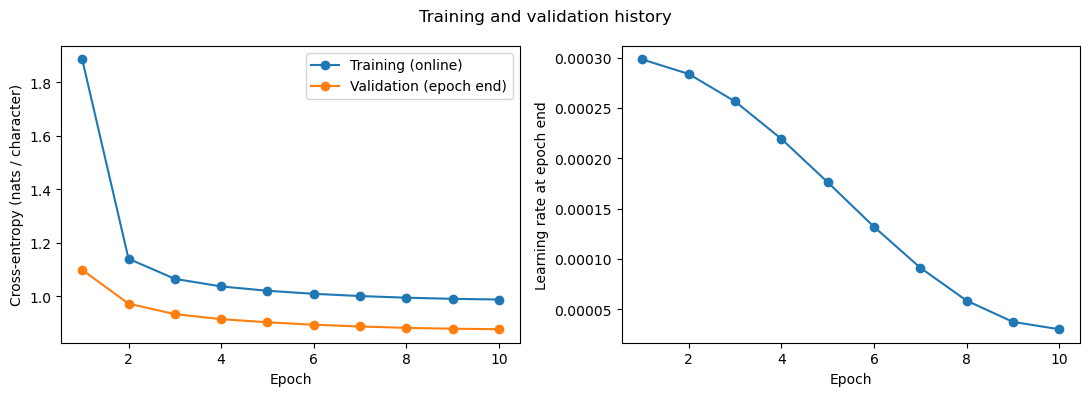

{
  "run_id": "train_20260914T211231Z_98b2aa86",
  "smoke": false,
  "completed_epochs": 10,
  "best_epoch": 10,
  "checkpoint": "task1_llm/Yuyao_Ding/checkpoints/train_20260914T211231Z_98b2aa86/epoch_010.pt",
  "checkpoint_sha256": "23933799df14748236f4a89d726f347a41485ba1885a9a654916d5be51c2eac6",
  "training_evaluation": {
    "cross_entropy": 0.876737655457606,
    "perplexity": 2.4030473364501996,
    "bits_per_character": 1.2648650676893047,
    "top1_accuracy": 0.7246622227343756,
    "target_tokens": 88792832
  },
  "validation_evaluation": {
    "cross_entropy": 0.8760242209402774,
    "perplexity": 2.4013335309502937,
    "bits_per_character": 1.263835799249156,
    "top1_accuracy": 0.7251761366982743,
    "target_tokens": 8693248
  },
  "generalization_gap": -0.0007134345173285261,
  "parameter_count": 456192,
  "training_seconds_excluding_evaluation_and_checkpoints": 7504.290094500999,
  "training_tokens_per_second": 118322.76055674566,
  "this_segment_wall_seconds": 7988.8

In [35]:
# Leave as None until formal training completes, or enter its outputs/train_... path.
SELECTED_RUN = None
if SELECTED_RUN is not None:
    selected_run_dir = repo_root / SELECTED_RUN
elif RUN_FORMAL_TRAINING:
    selected_run_dir = formal_run_dir
else:
    selected_run_dir = None

if selected_run_dir is None:
    print("No formal run selected; loss plots and trained text generation are pending.")
else:
    selected_metrics = json.loads((selected_run_dir / "metrics.json").read_text())
    if selected_metrics["smoke"]:
        raise ValueError("Select a formal training run, not smoke-test results.")
    selected_metrics = plot_training_run(selected_run_dir)
    print(json.dumps(selected_metrics, indent=2))
    generation_results = generate_from_run(
        selected_run_dir,
        prompts=["Once upon a time,", "A little girl found", "The dog wanted to"],
        max_new_tokens=300,
        device_name=training_config["device"],
        seed=training_config["seed"],
    )
